In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util
import propagation

2026-05-15 23:24:36,928 INFO: Setting up simulation


dx:  8.294591680169107e-11
N:  268435456
Species:  64


2026-05-15 23:24:37,342 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260515_232437184279


64 64


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-05-15 23:24:37.550] [info] 2D mode:
[2026-05-15 23:24:37.550] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260515_232437184279/00000000
[2026-05-15 23:24:38.722] [info] Simulating optical element 1/1
[2026-05-15 23:27:06.105] [info] Elapsed time for optical element: 147175.16 ms
[2026-05-15 23:27:07.272] [info] Simulation finished in 139.711930376 seconds


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [02:30<00:00, 150.68s/it]


nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


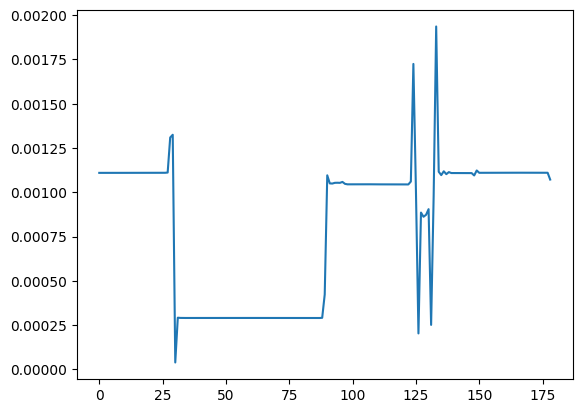

In [4]:
idt=[80]
for ii in idt:
    config_dict = {
        "sim_params": {
            "is2d":'false',
            "N": 2**28,
            "nx":2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-3.3e-6, 3.3e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251226,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_2e-4_2e-7_001.npy",
                "materials":[['SiO2',2.65],['C8H8',1.06],['C8H8',3.79],['C8H8',0.79]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.47], ['C8H8', 1.94], ['C8H8', 2.4], ['C8H8', 2.87], ['C8H8', 3.33], ['C8H8', 2.36], ['C8H8', 2.79], ['C8H8', 3.23], ['C8H8', 3.67], ['C8H8', 4.1], ['C8H8', 4.18], ['C8H8', 4.19], ['C8H8', 4.16], ['C8H8', 4.13], ['C8H8', 4.11], ['C8H8', 4.08], ['C8H8', 4.06], ['C8H8', 4.04], ['C8H8', 4.02], ['C8H8', 3.97], ['C8H8', 3.99], ['C8H8', 3.96], ['C8H8', 3.94], ['C8H8', 3.92], ['C8H8', 3.89], ['C8H8', 3.86], ['C8H8', 3.84], ['C8H8', 3.82], ['C8H8', 3.79], ['C8H8', 3.78], ['C8H8', 3.76], ['C8H8', 3.87], ['C8H8', 3.73], ['C8H8', 3.08], ['C8H8', 2.51], ['C8H8', 1.93], ['C8H8', 1.36], ['C8H8', 0.79], ['C8H8', 0.66], ['C8H8', 0.59], ['C8H8', 0.53], ['C8H8', 0.47], ['C8H8', 0.41], ['C8H8', 0.37], ['C8H8', 0.33], ['C8H8', 0.3], ['C8H8', 0.26], ['C8H8', 0.23], ['C8H8', 0.22], ['C8H8', 0.21], ['C8H8', 0.19], ['C8H8', 0.18], ['C8H8', 0.16], ['C8H8', 0.15], ['C8H8', 0.13], ['C8H8', 0.12], ['C8H8', 0.1], ['C8H8', 0.09], ['C8H8', 0.07], ['C8H8', 0.06], ['C8H8', 0.04], ['C8H8', 0.03]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.66], ['SiO2', 2.69], ['SiO2', 2.72], ['SiO2', 2.75], ['SiO2', 2.78], ['SiO2', 2.97], ['SiO2', 3.83], ['SiO2', 4.7], ['SiO2', 5.56], ['SiO2', 6.43], ['SiO2', 7.01], ['SiO2', 6.99], ['SiO2', 6.97], ['SiO2', 6.94], ['SiO2', 6.93], ['SiO2', 6.9], ['SiO2', 6.88], ['SiO2', 6.86], ['SiO2', 6.85], ['SiO2', 6.83], ['SiO2', 6.8], ['SiO2', 6.77], ['SiO2', 6.75], ['SiO2', 6.73], ['SiO2', 6.71], ['SiO2', 6.69], ['SiO2', 6.68], ['SiO2', 6.66], ['SiO2', 6.64], ['SiO2', 6.58], ['SiO2', 6.56], ['SiO2', 6.54], ['SiO2', 6.52], ['SiO2', 6.5], ['SiO2', 6.48], ['SiO2', 6.46], ['SiO2', 6.44], ['SiO2', 6.41], ['SiO2', 6.39], ['SiO2', 6.37], ['SiO2', 6.35], ['SiO2', 6.32], ['SiO2', 6.3], ['SiO2', 6.27], ['SiO2', 6.28], ['SiO2', 6.24], ['SiO2', 6.22], ['SiO2', 6.19], ['SiO2', 6.11], ['SiO2', 6.06], ['SiO2', 6.03], ['SiO2', 6.02], ['SiO2', 5.97], ['SiO2', 5.95], ['SiO2', 5.93], ['SiO2', 5.9], ['SiO2', 5.88], ['SiO2', 5.86], ['SiO2', 5.84], ['SiO2', 5.79], ['SiO2', 5.77], ['SiO2', 5.74], ['SiO2', 5.71], ['SiO2', 5.68], ['SiO2', 5.66], ['SiO2', 5.64], ['SiO2', 5.58], ['SiO2', 5.52], ['SiO2', 5.5], ['SiO2', 5.46], ['SiO2', 5.44], ['SiO2', 5.43], ['SiO2', 5.41], ['SiO2', 5.39], ['C8H8', 5.15], ['C8H8', 4.77], ['C8H8', 4.39], ['C8H8', 4.01], ['C8H8', 3.63], ['C8H8', 3.48], ['C8H8', 3.49], ['C8H8', 3.51], ['C8H8', 3.46], ['C8H8', 3.43], ['C8H8', 3.41], ['C8H8', 3.39], ['C8H8', 3.38], ['C8H8', 3.36], ['C8H8', 3.33], ['C8H8', 3.32], ['C8H8', 3.3], ['C8H8', 3.28], ['C8H8', 3.25], ['C8H8', 3.23], ['C8H8', 3.21], ['C8H8', 3.19], ['C8H8', 3.16], ['C8H8', 3.15], ['C8H8', 3.13], ['C8H8', 3.09], ['C8H8', 3.07], ['C8H8', 3.05], ['C8H8', 3.01], ['C8H8', 2.99], ['C8H8', 2.98], ['C8H8', 2.96], ['C8H8', 2.94], ['C8H8', 2.91], ['C8H8', 2.9], ['C8H8', 2.88], ['C8H8', 2.86], ['C8H8', 2.84], ['C8H8', 2.82], ['C8H8', 2.79], ['C8H8', 2.78], ['C8H8', 2.76], ['C8H8', 2.74], ['C8H8', 2.72], ['C8H8', 2.71], ['C8H8', 2.69], ['C8H8', 2.67], ['C8H8', 2.65], ['C8H8', 2.63], ['C8H8', 2.61], ['C8H8', 2.59], ['C8H8', 2.57], ['C8H8', 2.55], ['C8H8', 2.53], ['C8H8', 2.51], ['C8H8', 2.49], ['C8H8', 2.48], ['C8H8', 2.46], ['C8H8', 2.43], ['C8H8', 2.42], ['C8H8', 2.4], ['C8H8', 2.38], ['C8H8', 2.36], ['C8H8', 2.34], ['C8H8', 2.32], ['C8H8', 2.3], ['C8H8', 2.28], ['C8H8', 2.26], ['C8H8', 2.24], ['C8H8', 2.22], ['C8H8', 2.2], ['C8H8', 2.17], ['C8H8', 2.15], ['C8H8', 2.12], ['C8H8', 1.95], ['C8H8', 1.89], ['C8H8', 1.83], ['C8H8', 1.77], ['C8H8', 1.71], ['C8H8', 1.54], ['C8H8', 1.53], ['C8H8', 1.52], ['C8H8', 1.51], ['C8H8', 1.5], ['C8H8', 1.49], ['C8H8', 1.48], ['C8H8', 1.47], ['C8H8', 1.46], ['C8H8', 1.45], ['C8H8', 1.44], ['C8H8', 1.43], ['C8H8', 1.42], ['C8H8', 1.41], ['C8H8', 1.4], ['C8H8', 1.39], ['C8H8', 1.38], ['C8H8', 1.36], ['C8H8', 1.35], ['C8H8', 1.34], ['C8H8', 1.33], ['C8H8', 1.32], ['C8H8', 1.31], ['C8H8', 1.29], ['C8H8', 1.28], ['C8H8', 1.27], ['C8H8', 1.26], ['C8H8', 1.25], ['C8H8', 1.24], ['C8H8', 1.23], ['C8H8', 1.22], ['C8H8', 1.21], ['C8H8', 1.2], ['C8H8', 1.18], ['C8H8', 1.17], ['C8H8', 1.16], ['C8H8', 1.15], ['C8H8', 1.14], ['C8H8', 1.13], ['C8H8', 1.11], ['C8H8', 1.1], ['C8H8', 1.09], ['C8H8', 1.08], ['C8H8', 1.07], ['C8H8', 1.06], ['C8H8', 1.05], ['C8H8', 1.03], ['C8H8', 1.02], ['C8H8', 1.01], ['C8H8', 1.0], ['C8H8', 0.99], ['C8H8', 0.98], ['C8H8', 0.97], ['C8H8', 0.96], ['C8H8', 0.95], ['C8H8', 0.94], ['C8H8', 0.92], ['C8H8', 0.91], ['C8H8', 0.9], ['C8H8', 0.89], ['C8H8', 0.88], ['C8H8', 0.87], ['C8H8', 0.86], ['C8H8', 0.85], ['C8H8', 0.84], ['C8H8', 0.83], ['C8H8', 0.82], ['C8H8', 0.8], ['C8H8', 0.79], ['C8H8', 0.78], ['C8H8', 0.77], ['C8H8', 0.76], ['C8H8', 0.75], ['C8H8', 0.74], ['C8H8', 0.73], ['C8H8', 0.72], ['C8H8', 0.71], ['C8H8', 0.7], ['C8H8', 0.69], ['C8H8', 0.67], ['C8H8', 0.66], ['C8H8', 0.65], ['C8H8', 0.64], ['C8H8', 0.63], ['C8H8', 0.62], ['C8H8', 0.61], ['C8H8', 0.6], ['C8H8', 0.59], ['C8H8', 0.58], ['C8H8', 0.57], ['C8H8', 0.55], ['C8H8', 0.54], ['C8H8', 0.53], ['C8H8', 0.52], ['C8H8', 0.51], ['C8H8', 0.5], ['C8H8', 0.49], ['C8H8', 0.48], ['C8H8', 0.47], ['C8H8', 0.45], ['C8H8', 0.42], ['C8H8', 0.4], ['C8H8', 0.37], ['C8H8', 0.34], ['C8H8', 0.32], ['C8H8', 0.29], ['C8H8', 0.26], ['C8H8', 0.24], ['C8H8', 0.21], ['C8H8', 0.18], ['C8H8', 0.16], ['C8H8', 0.15], ['C8H8', 0.13], ['C8H8', 0.12], ['C8H8', 0.1], ['C8H8', 0.09], ['C8H8', 0.07], ['C8H8', 0.06], ['C8H8', 0.04], ['C8H8', 0.03]]
    if ii==1:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    # from contextlib import redirect_stdout
    # with open('output_shocksample_shot_'+str(config_dict["multisource"]["nr_source_points"])+'_sample'+str(ii)+'.txt', 'w') as file:
    #     with redirect_stdout(file):
    #         for i in range(len(wf[0])):
    #             print(wf[0][i])
    # print(detector_x)

2026-01-20 10:45:29,013 INFO: Setting up simulation


dx:  8.294591680169107e-11
N:  268435456
Species:  64


2026-01-20 10:45:29,404 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260120_104529242296


64 64


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-01-20 10:45:29.647] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260120_104529242296/00000000
[2026-01-20 10:45:30.269] [info] Simulating optical element 1/1
[2026-01-20 10:47:03.327] [info] Elapsed time for optical element: 92980.5 ms


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:34<00:00, 94.23s/it]

[2026-01-20 10:47:03.540] [info] Simulation finished in 99.454907005 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


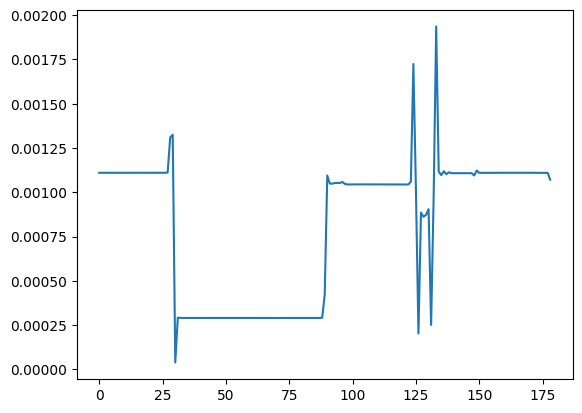

In [4]:
idt=[80]
for ii in idt:
    config_dict = {
        "sim_params": {
            "N": 2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-3.3e-6, 3.3e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251226,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_2e-4_2e-7_001.npy",
                "materials":[['SiO2',2.65],['C8H8',1.06],['C8H8',3.79],['C8H8',0.79]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.47], ['C8H8', 1.94], ['C8H8', 2.4], ['C8H8', 2.87], ['C8H8', 3.33], ['C8H8', 2.36], ['C8H8', 2.79], ['C8H8', 3.23], ['C8H8', 3.67], ['C8H8', 4.1], ['C8H8', 4.18], ['C8H8', 4.19], ['C8H8', 4.16], ['C8H8', 4.13], ['C8H8', 4.11], ['C8H8', 4.08], ['C8H8', 4.06], ['C8H8', 4.04], ['C8H8', 4.02], ['C8H8', 3.97], ['C8H8', 3.99], ['C8H8', 3.96], ['C8H8', 3.94], ['C8H8', 3.92], ['C8H8', 3.89], ['C8H8', 3.86], ['C8H8', 3.84], ['C8H8', 3.82], ['C8H8', 3.79], ['C8H8', 3.78], ['C8H8', 3.76], ['C8H8', 3.87], ['C8H8', 3.73], ['C8H8', 3.08], ['C8H8', 2.51], ['C8H8', 1.93], ['C8H8', 1.36], ['C8H8', 0.79], ['C8H8', 0.66], ['C8H8', 0.59], ['C8H8', 0.53], ['C8H8', 0.47], ['C8H8', 0.41], ['C8H8', 0.37], ['C8H8', 0.33], ['C8H8', 0.3], ['C8H8', 0.26], ['C8H8', 0.23], ['C8H8', 0.22], ['C8H8', 0.21], ['C8H8', 0.19], ['C8H8', 0.18], ['C8H8', 0.16], ['C8H8', 0.15], ['C8H8', 0.13], ['C8H8', 0.12], ['C8H8', 0.1], ['C8H8', 0.09], ['C8H8', 0.07], ['C8H8', 0.06], ['C8H8', 0.04], ['C8H8', 0.03]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.66], ['SiO2', 2.69], ['SiO2', 2.72], ['SiO2', 2.75], ['SiO2', 2.78], ['SiO2', 2.97], ['SiO2', 3.83], ['SiO2', 4.7], ['SiO2', 5.56], ['SiO2', 6.43], ['SiO2', 7.01], ['SiO2', 6.99], ['SiO2', 6.97], ['SiO2', 6.94], ['SiO2', 6.93], ['SiO2', 6.9], ['SiO2', 6.88], ['SiO2', 6.86], ['SiO2', 6.85], ['SiO2', 6.83], ['SiO2', 6.8], ['SiO2', 6.77], ['SiO2', 6.75], ['SiO2', 6.73], ['SiO2', 6.71], ['SiO2', 6.69], ['SiO2', 6.68], ['SiO2', 6.66], ['SiO2', 6.64], ['SiO2', 6.58], ['SiO2', 6.56], ['SiO2', 6.54], ['SiO2', 6.52], ['SiO2', 6.5], ['SiO2', 6.48], ['SiO2', 6.46], ['SiO2', 6.44], ['SiO2', 6.41], ['SiO2', 6.39], ['SiO2', 6.37], ['SiO2', 6.35], ['SiO2', 6.32], ['SiO2', 6.3], ['SiO2', 6.27], ['SiO2', 6.28], ['SiO2', 6.24], ['SiO2', 6.22], ['SiO2', 6.19], ['SiO2', 6.11], ['SiO2', 6.06], ['SiO2', 6.03], ['SiO2', 6.02], ['SiO2', 5.97], ['SiO2', 5.95], ['SiO2', 5.93], ['SiO2', 5.9], ['SiO2', 5.88], ['SiO2', 5.86], ['SiO2', 5.84], ['SiO2', 5.79], ['SiO2', 5.77], ['SiO2', 5.74], ['SiO2', 5.71], ['SiO2', 5.68], ['SiO2', 5.66], ['SiO2', 5.64], ['SiO2', 5.58], ['SiO2', 5.52], ['SiO2', 5.5], ['SiO2', 5.46], ['SiO2', 5.44], ['SiO2', 5.43], ['SiO2', 5.41], ['SiO2', 5.39], ['C8H8', 5.15], ['C8H8', 4.77], ['C8H8', 4.39], ['C8H8', 4.01], ['C8H8', 3.63], ['C8H8', 3.48], ['C8H8', 3.49], ['C8H8', 3.51], ['C8H8', 3.46], ['C8H8', 3.43], ['C8H8', 3.41], ['C8H8', 3.39], ['C8H8', 3.38], ['C8H8', 3.36], ['C8H8', 3.33], ['C8H8', 3.32], ['C8H8', 3.3], ['C8H8', 3.28], ['C8H8', 3.25], ['C8H8', 3.23], ['C8H8', 3.21], ['C8H8', 3.19], ['C8H8', 3.16], ['C8H8', 3.15], ['C8H8', 3.13], ['C8H8', 3.09], ['C8H8', 3.07], ['C8H8', 3.05], ['C8H8', 3.01], ['C8H8', 2.99], ['C8H8', 2.98], ['C8H8', 2.96], ['C8H8', 2.94], ['C8H8', 2.91], ['C8H8', 2.9], ['C8H8', 2.88], ['C8H8', 2.86], ['C8H8', 2.84], ['C8H8', 2.82], ['C8H8', 2.79], ['C8H8', 2.78], ['C8H8', 2.76], ['C8H8', 2.74], ['C8H8', 2.72], ['C8H8', 2.71], ['C8H8', 2.69], ['C8H8', 2.67], ['C8H8', 2.65], ['C8H8', 2.63], ['C8H8', 2.61], ['C8H8', 2.59], ['C8H8', 2.57], ['C8H8', 2.55], ['C8H8', 2.53], ['C8H8', 2.51], ['C8H8', 2.49], ['C8H8', 2.48], ['C8H8', 2.46], ['C8H8', 2.43], ['C8H8', 2.42], ['C8H8', 2.4], ['C8H8', 2.38], ['C8H8', 2.36], ['C8H8', 2.34], ['C8H8', 2.32], ['C8H8', 2.3], ['C8H8', 2.28], ['C8H8', 2.26], ['C8H8', 2.24], ['C8H8', 2.22], ['C8H8', 2.2], ['C8H8', 2.17], ['C8H8', 2.15], ['C8H8', 2.12], ['C8H8', 1.95], ['C8H8', 1.89], ['C8H8', 1.83], ['C8H8', 1.77], ['C8H8', 1.71], ['C8H8', 1.54], ['C8H8', 1.53], ['C8H8', 1.52], ['C8H8', 1.51], ['C8H8', 1.5], ['C8H8', 1.49], ['C8H8', 1.48], ['C8H8', 1.47], ['C8H8', 1.46], ['C8H8', 1.45], ['C8H8', 1.44], ['C8H8', 1.43], ['C8H8', 1.42], ['C8H8', 1.41], ['C8H8', 1.4], ['C8H8', 1.39], ['C8H8', 1.38], ['C8H8', 1.36], ['C8H8', 1.35], ['C8H8', 1.34], ['C8H8', 1.33], ['C8H8', 1.32], ['C8H8', 1.31], ['C8H8', 1.29], ['C8H8', 1.28], ['C8H8', 1.27], ['C8H8', 1.26], ['C8H8', 1.25], ['C8H8', 1.24], ['C8H8', 1.23], ['C8H8', 1.22], ['C8H8', 1.21], ['C8H8', 1.2], ['C8H8', 1.18], ['C8H8', 1.17], ['C8H8', 1.16], ['C8H8', 1.15], ['C8H8', 1.14], ['C8H8', 1.13], ['C8H8', 1.11], ['C8H8', 1.1], ['C8H8', 1.09], ['C8H8', 1.08], ['C8H8', 1.07], ['C8H8', 1.06], ['C8H8', 1.05], ['C8H8', 1.03], ['C8H8', 1.02], ['C8H8', 1.01], ['C8H8', 1.0], ['C8H8', 0.99], ['C8H8', 0.98], ['C8H8', 0.97], ['C8H8', 0.96], ['C8H8', 0.95], ['C8H8', 0.94], ['C8H8', 0.92], ['C8H8', 0.91], ['C8H8', 0.9], ['C8H8', 0.89], ['C8H8', 0.88], ['C8H8', 0.87], ['C8H8', 0.86], ['C8H8', 0.85], ['C8H8', 0.84], ['C8H8', 0.83], ['C8H8', 0.82], ['C8H8', 0.8], ['C8H8', 0.79], ['C8H8', 0.78], ['C8H8', 0.77], ['C8H8', 0.76], ['C8H8', 0.75], ['C8H8', 0.74], ['C8H8', 0.73], ['C8H8', 0.72], ['C8H8', 0.71], ['C8H8', 0.7], ['C8H8', 0.69], ['C8H8', 0.67], ['C8H8', 0.66], ['C8H8', 0.65], ['C8H8', 0.64], ['C8H8', 0.63], ['C8H8', 0.62], ['C8H8', 0.61], ['C8H8', 0.6], ['C8H8', 0.59], ['C8H8', 0.58], ['C8H8', 0.57], ['C8H8', 0.55], ['C8H8', 0.54], ['C8H8', 0.53], ['C8H8', 0.52], ['C8H8', 0.51], ['C8H8', 0.5], ['C8H8', 0.49], ['C8H8', 0.48], ['C8H8', 0.47], ['C8H8', 0.45], ['C8H8', 0.42], ['C8H8', 0.4], ['C8H8', 0.37], ['C8H8', 0.34], ['C8H8', 0.32], ['C8H8', 0.29], ['C8H8', 0.26], ['C8H8', 0.24], ['C8H8', 0.21], ['C8H8', 0.18], ['C8H8', 0.16], ['C8H8', 0.15], ['C8H8', 0.13], ['C8H8', 0.12], ['C8H8', 0.1], ['C8H8', 0.09], ['C8H8', 0.07], ['C8H8', 0.06], ['C8H8', 0.04], ['C8H8', 0.03]]
    if ii==1:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_shocksample_shot_'+str(config_dict["multisource"]["nr_source_points"])+'_sample'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    # print(detector_x)

2026-01-19 17:12:29,337 INFO: Setting up simulation
2026-01-19 17:12:29,444 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_171229381385


dx:  8.294591680169107e-11
N:  268435456
Species:  4
4 4


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-01-19 17:12:29.604] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_171229381385/00000000
[2026-01-19 17:12:30.115] [info] Simulating optical element 1/1
[2026-01-19 17:12:30.117] [info] PreciseSample info:
[2026-01-19 17:12:30.117] [info]   z_len: 1000, x_len: 2000
[2026-01-19 17:12:30.117] [info]   material_deltabetas size: 5
[2026-01-19 17:12:30.117] [info]   Material 0: (0, 0)
[2026-01-19 17:12:30.117] [info]   Material 1: (6.853618917444699e-06, 7.349540877870883e-08)
[2026-01-19 17:12:30.117] [info]   Material 2: (2.9288325139366256e-06, 3.3519561674470594e-09)
[2026-01-19 17:12:30.117] [info]   Material 3: (1.0471957762094162e-05, 1.1984824410022977e-08)
[2026-01-19 17:12:30.117] [info]   Material 4: (2.182809137745221e-06, 2.4981560115879033e-09)
[2026-01-19 17:14:04.666] [info] Elapsed time for optical element: 94670.18 ms


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:35<00:00, 95.54s/it]

[2026-01-19 17:14:04.886] [info] Simulation finished in 95.788631403 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


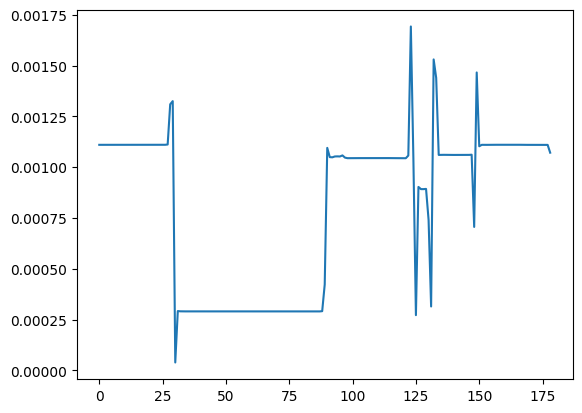

In [4]:
idt=[1]
for ii in idt:
    config_dict = {
        "sim_params": {
            "N": 2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-3.3e-6, 3.3e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251226,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                # "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_1e-3_2e-7_001.npy",
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_shcokwave_sample_80.npy",
                #80
                
                "materials":[['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8',1.06], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.472567], ['C8H8', 1.93762], ['C8H8', 2.402672], ['C8H8', 2.867725], ['C8H8', 3.332777], ['C8H8', 2.358152], ['C8H8', 2.79413], ['C8H8', 3.230108], ['C8H8', 3.666086], ['C8H8', 4.102064], ['C8H8', 4.181372], ['C8H8', 4.192097], ['C8H8', 4.168791], ['C8H8', 4.157365], ['C8H8', 4.145939], ['C8H8', 4.134514], ['C8H8', 4.119286], ['C8H8', 4.083412], ['C8H8', 4.065603], ['C8H8', 4.052678], ['C8H8', 4.034355], ['C8H8', 4.020007], ['C8H8', 3.967215], ['C8H8', 3.980062], ['C8H8', 3.992908], ['C8H8', 4.005254], ['C8H8', 3.940929], ['C8H8', 3.9231], ['C8H8', 3.905271], ['C8H8', 3.887442], ['C8H8', 3.864106], ['C8H8', 3.841035], ['C8H8', 3.817963], ['C8H8', 3.794891], ['C8H8', 3.775807], ['C8H8', 3.76336], ['C8H8', 3.851788], ['C8H8', 3.951348], ['C8H8', 3.726529], ['C8H8', 3.076403], ['C8H8', 2.505498], ['C8H8', 1.363687], ['C8H8', 0.792781], ['C8H8', 0.656895], ['C8H8', 0.594784], ['C8H8', 0.532673], ['C8H8', 0.470562], ['C8H8', 0.408451], ['C8H8', 0.369521], ['C8H8', 0.334443], ['C8H8', 0.299366], ['C8H8', 0.264288], ['C8H8', 0.229211], ['C8H8', 0.21643], ['C8H8', 0.198127], ['C8H8', 0.179825], ['C8H8', 0.161522], ['C8H8', 0.14322], ['C8H8', 0.124918], ['C8H8', 0.106615], ['C8H8', 0.088313], ['C8H8', 0.078172], ['C8H8', 0.067958], ['C8H8', 0.057744], ['C8H8', 0.047531], ['C8H8', 0.037287], ['C8H8', 0.027261], ['C8H8', 0.017236]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.660634], ['SiO2', 2.689968], ['SiO2', 2.719303], ['SiO2', 2.748638], ['SiO2', 2.777972], ['SiO2', 2.965927], ['SiO2', 3.83148], ['SiO2', 4.697032], ['SiO2', 5.562585], ['SiO2', 6.428138], ['SiO2', 7.014069], ['SiO2', 6.998661], ['SiO2', 6.983253], ['SiO2', 6.96666], ['SiO2', 6.955754], ['SiO2', 6.944849], ['SiO2', 6.933943], ['SiO2', 6.917133], ['SiO2', 6.899504], ['SiO2', 6.881876], ['SiO2', 6.864247], ['SiO2', 6.846618], ['SiO2', 6.834928], ['SiO2', 6.803993], ['SiO2', 6.773057], ['SiO2', 6.75056], ['SiO2', 6.73093], ['SiO2', 6.7113], ['SiO2', 6.69167], ['SiO2', 6.676234], ['SiO2', 6.658265], ['SiO2', 6.640296], ['SiO2', 6.582478], ['SiO2', 6.56511], ['SiO2', 6.547741], ['SiO2', 6.518184], ['SiO2', 6.497233], ['SiO2', 6.476283], ['SiO2', 6.455332], ['SiO2', 6.438912], ['SiO2', 6.405775], ['SiO2', 6.389207], ['SiO2', 6.371915], ['SiO2', 6.347083], ['SiO2', 6.322251], ['SiO2', 6.297418], ['SiO2', 6.272586], ['SiO2', 6.243858], ['SiO2', 6.231595], ['SiO2', 6.218689], ['SiO2', 6.205783], ['SiO2', 6.192876], ['SiO2', 6.11143], ['SiO2', 6.057242], ['SiO2', 6.046096], ['SiO2', 6.034951], ['SiO2', 6.023805], ['SiO2', 6.012659], ['SiO2', 5.973823], ['SiO2', 5.954253], ['SiO2', 5.934684], ['SiO2', 5.915114], ['SiO2', 5.895544], ['SiO2', 5.880792], ['SiO2', 5.859542], ['SiO2', 5.838291], ['SiO2', 5.789014], ['SiO2', 5.772886], ['SiO2', 5.756758], ['SiO2', 5.737114], ['SiO2', 5.710741], ['SiO2', 5.684367], ['SiO2', 5.657994], ['SiO2', 5.642045], ['SiO2', 5.583917], ['SiO2', 5.520054], ['SiO2', 5.507508], ['SiO2', 5.461704], ['SiO2', 5.444095], ['SiO2', 5.426487], ['SiO2', 5.408878], ['SiO2', 5.391269], ['C8H8', 5.154639], ['C8H8', 4.773428], ['C8H8', 4.392217], ['C8H8', 4.011007], ['C8H8', 3.629796], ['C8H8', 3.47748], ['C8H8', 3.496209], ['C8H8', 3.514939], ['C8H8', 3.46373], ['C8H8', 3.448743], ['C8H8', 3.427242], ['C8H8', 3.408452], ['C8H8', 3.389663], ['C8H8', 3.379072], ['C8H8', 3.363644], ['C8H8', 3.348217], ['C8H8', 3.327711], ['C8H8', 3.316265], ['C8H8', 3.304819], ['C8H8', 3.28322], ['C8H8', 3.265751], ['C8H8', 3.248282], ['C8H8', 3.227283], ['C8H8', 3.212976], ['C8H8', 3.201172], ['C8H8', 3.190107], ['C8H8', 3.179041], ['C8H8', 3.155514], ['C8H8', 3.140747], ['C8H8', 3.125979], ['C8H8', 3.089821], ['C8H8', 3.075614], ['C8H8', 3.061407], ['C8H8', 3.047574], ['C8H8', 3.036088], ['C8H8', 3.010959], ['C8H8', 2.995752], ['C8H8', 2.980544], ['C8H8', 2.969093], ['C8H8', 2.958848], ['C8H8', 2.948603], ['C8H8', 2.938358], ['C8H8', 2.911571], ['C8H8', 2.901546], ['C8H8', 2.881413], ['C8H8', 2.869107], ['C8H8', 2.850827], ['C8H8', 2.839221], ['C8H8', 2.827615], ['C8H8', 2.816009], ['C8H8', 2.793787], ['C8H8', 2.777819], ['C8H8', 2.761851], ['C8H8', 2.751419], ['C8H8', 2.737412], ['C8H8', 2.72198], ['C8H8', 2.707813], ['C8H8', 2.692889], ['C8H8', 2.678375], ['C8H8', 2.664088], ['C8H8', 2.648603], ['C8H8', 2.635476], ['C8H8', 2.619519], ['C8H8', 2.606793], ['C8H8', 2.589811], ['C8H8', 2.577329], ['C8H8', 2.565843], ['C8H8', 2.554109], ['C8H8', 2.528559], ['C8H8', 2.513611], ['C8H8', 2.498199], ['C8H8', 2.482391], ['C8H8', 2.468045], ['C8H8', 2.456346], ['C8H8', 2.446021], ['C8H8', 2.432778], ['C8H8', 2.419091], ['C8H8', 2.405405], ['C8H8', 2.393327], ['C8H8', 2.382034], ['C8H8', 2.368307], ['C8H8', 2.35458], ['C8H8', 2.341223], ['C8H8', 2.329632], ['C8H8', 2.317546], ['C8H8', 2.298229], ['C8H8', 2.287584], ['C8H8', 2.274456], ['C8H8', 2.259088], ['C8H8', 2.24329], ['C8H8', 2.21939], ['C8H8', 2.195638], ['C8H8', 2.171886], ['C8H8', 2.148134], ['C8H8', 2.124382], ['C8H8', 1.94572], ['C8H8', 1.88709], ['C8H8', 1.828461], ['C8H8', 1.769832], ['C8H8', 1.711202], ['C8H8', 1.542975], ['C8H8', 1.529608], ['C8H8', 1.516241], ['C8H8', 1.506145], ['C8H8', 1.488307], ['C8H8', 1.471533], ['C8H8', 1.455424], ['C8H8', 1.435671], ['C8H8', 1.418988], ['C8H8', 1.406517], ['C8H8', 1.394991], ['C8H8', 1.381576], ['C8H8', 1.366454], ['C8H8', 1.356429], ['C8H8', 1.345234], ['C8H8', 1.326831], ['C8H8', 1.314679], ['C8H8', 1.291232], ['C8H8', 1.279182], ['C8H8', 1.267335], ['C8H8', 1.25287], ['C8H8', 1.242184], ['C8H8', 1.229417], ['C8H8', 1.216007], ['C8H8', 1.20211], ['C8H8', 1.181088], ['C8H8', 1.165589], ['C8H8', 1.152142], ['C8H8', 1.136553], ['C8H8', 1.125228], ['C8H8', 1.11191], ['C8H8', 1.099998], ['C8H8', 1.087391], ['C8H8', 1.075244], ['C8H8', 1.057239], ['C8H8', 1.026002], ['C8H8', 1.015557], ['C8H8', 1.004741], ['C8H8', 0.992404], ['C8H8', 0.981071], ['C8H8', 0.968152], ['C8H8', 0.95594], ['C8H8', 0.94334], ['C8H8', 0.932484], ['C8H8', 0.921537], ['C8H8', 0.907734], ['C8H8', 0.894444], ['C8H8', 0.877199], ['C8H8', 0.866644], ['C8H8', 0.856321], ['C8H8', 0.842184], ['C8H8', 0.830571], ['C8H8', 0.820555], ['C8H8', 0.807186], ['C8H8', 0.796331], ['C8H8', 0.78252], ['C8H8', 0.768961], ['C8H8', 0.757252], ['C8H8', 0.746854], ['C8H8', 0.735762], ['C8H8', 0.725554], ['C8H8', 0.715493], ['C8H8', 0.704549], ['C8H8', 0.692516], ['C8H8', 0.681846], ['C8H8', 0.671272], ['C8H8', 0.658949], ['C8H8', 0.647926], ['C8H8', 0.63639], ['C8H8', 0.624077], ['C8H8', 0.612836], ['C8H8', 0.601977], ['C8H8', 0.591413], ['C8H8', 0.577759], ['C8H8', 0.567019], ['C8H8', 0.556665], ['C8H8', 0.545423], ['C8H8', 0.535338], ['C8H8', 0.524777], ['C8H8', 0.513655], ['C8H8', 0.50231], ['C8H8', 0.490834], ['C8H8', 0.477796], ['C8H8', 0.467591], ['C8H8', 0.452482], ['C8H8', 0.424323], ['C8H8', 0.397469], ['C8H8', 0.370616], ['C8H8', 0.343763], ['C8H8', 0.316909], ['C8H8', 0.290056], ['C8H8', 0.263202], ['C8H8', 0.236349], ['C8H8', 0.209495], ['C8H8', 0.182642], ['C8H8', 0.169441], ['C8H8', 0.15734], ['C8H8', 0.14524], ['C8H8', 0.13314], ['C8H8', 0.121039], ['C8H8', 0.108939], ['C8H8', 0.096839], ['C8H8', 0.084738], ['C8H8', 0.072638], ['C8H8', 0.060538], ['C8H8', 0.048437], ['C8H8', 0.036337], ['C8H8', 0.026323]]
    if ii==1:
        config_dict["elements"][0]["materials"]=[['SiO2',2.65], ['C8H8',1.06], ['C8H8',3.79], ['C8H8',0.79]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_time_shocksample_'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    # print(detector_x)

2025-12-26 00:56:23,065 INFO: Setting up simulation


dx:  8.294591680169107e-11
N:  268435456
Species:  16


2025-12-26 00:56:23,383 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_005623163806
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2025-12-26 00:56:23.652] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_005623163806/00000000
[2025-12-26 00:56:24.324] [info] Simulating optical element 1/1
[2025-12-26 00:56:24.333] [info] PreciseSample info:
[2025-12-26 00:56:24.334] [info]   z_len: 5000, x_len: 2000
[2025-12-26 00:56:24.334] [info]   material_deltabetas size: 17
[2025-12-26 00:56:24.334] [info]   Material 0: (0, 0)
[2025-12-26 00:56:24.334] [info]   Material 1: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:56:24.334] [info]   Material 2: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:56:24.334] [info]   Material 3: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:56:24.334] [info]   Material 4: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:56:24.334] [info]   Material 5: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:56:24.334] [info]   Material 6: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [07:55<00:00, 475.41s/it]

[2025-12-26 01:04:18.655] [info] Simulation finished in 505.998428593 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


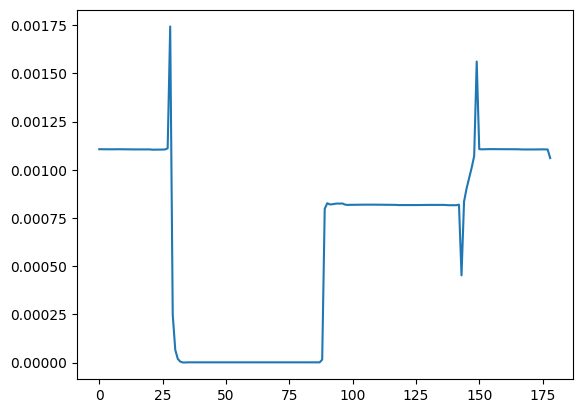

In [4]:
idt=[1]
for ii in idt:
    config_dict = {
        "sim_params": {
            "N": 2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-1e-7, 1e-7],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251225,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                # "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_1e-3_2e-7_001.npy",
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_16merge_sample.npy",
                #80
                
                "materials":[['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65],  ['SiO2', 2.65], ['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06],['C8H8',1.06], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.472567], ['C8H8', 1.93762], ['C8H8', 2.402672], ['C8H8', 2.867725], ['C8H8', 3.332777], ['C8H8', 2.358152], ['C8H8', 2.79413], ['C8H8', 3.230108], ['C8H8', 3.666086], ['C8H8', 4.102064], ['C8H8', 4.181372], ['C8H8', 4.192097], ['C8H8', 4.168791], ['C8H8', 4.157365], ['C8H8', 4.145939], ['C8H8', 4.134514], ['C8H8', 4.119286], ['C8H8', 4.083412], ['C8H8', 4.065603], ['C8H8', 4.052678], ['C8H8', 4.034355], ['C8H8', 4.020007], ['C8H8', 3.967215], ['C8H8', 3.980062], ['C8H8', 3.992908], ['C8H8', 4.005254], ['C8H8', 3.940929], ['C8H8', 3.9231], ['C8H8', 3.905271], ['C8H8', 3.887442], ['C8H8', 3.864106], ['C8H8', 3.841035], ['C8H8', 3.817963], ['C8H8', 3.794891], ['C8H8', 3.775807], ['C8H8', 3.76336], ['C8H8', 3.851788], ['C8H8', 3.951348], ['C8H8', 3.726529], ['C8H8', 3.076403], ['C8H8', 2.505498], ['C8H8', 1.363687], ['C8H8', 0.792781], ['C8H8', 0.656895], ['C8H8', 0.594784], ['C8H8', 0.532673], ['C8H8', 0.470562], ['C8H8', 0.408451], ['C8H8', 0.369521], ['C8H8', 0.334443], ['C8H8', 0.299366], ['C8H8', 0.264288], ['C8H8', 0.229211], ['C8H8', 0.21643], ['C8H8', 0.198127], ['C8H8', 0.179825], ['C8H8', 0.161522], ['C8H8', 0.14322], ['C8H8', 0.124918], ['C8H8', 0.106615], ['C8H8', 0.088313], ['C8H8', 0.078172], ['C8H8', 0.067958], ['C8H8', 0.057744], ['C8H8', 0.047531], ['C8H8', 0.037287], ['C8H8', 0.027261], ['C8H8', 0.017236]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.660634], ['SiO2', 2.689968], ['SiO2', 2.719303], ['SiO2', 2.748638], ['SiO2', 2.777972], ['SiO2', 2.965927], ['SiO2', 3.83148], ['SiO2', 4.697032], ['SiO2', 5.562585], ['SiO2', 6.428138], ['SiO2', 7.014069], ['SiO2', 6.998661], ['SiO2', 6.983253], ['SiO2', 6.96666], ['SiO2', 6.955754], ['SiO2', 6.944849], ['SiO2', 6.933943], ['SiO2', 6.917133], ['SiO2', 6.899504], ['SiO2', 6.881876], ['SiO2', 6.864247], ['SiO2', 6.846618], ['SiO2', 6.834928], ['SiO2', 6.803993], ['SiO2', 6.773057], ['SiO2', 6.75056], ['SiO2', 6.73093], ['SiO2', 6.7113], ['SiO2', 6.69167], ['SiO2', 6.676234], ['SiO2', 6.658265], ['SiO2', 6.640296], ['SiO2', 6.582478], ['SiO2', 6.56511], ['SiO2', 6.547741], ['SiO2', 6.518184], ['SiO2', 6.497233], ['SiO2', 6.476283], ['SiO2', 6.455332], ['SiO2', 6.438912], ['SiO2', 6.405775], ['SiO2', 6.389207], ['SiO2', 6.371915], ['SiO2', 6.347083], ['SiO2', 6.322251], ['SiO2', 6.297418], ['SiO2', 6.272586], ['SiO2', 6.243858], ['SiO2', 6.231595], ['SiO2', 6.218689], ['SiO2', 6.205783], ['SiO2', 6.192876], ['SiO2', 6.11143], ['SiO2', 6.057242], ['SiO2', 6.046096], ['SiO2', 6.034951], ['SiO2', 6.023805], ['SiO2', 6.012659], ['SiO2', 5.973823], ['SiO2', 5.954253], ['SiO2', 5.934684], ['SiO2', 5.915114], ['SiO2', 5.895544], ['SiO2', 5.880792], ['SiO2', 5.859542], ['SiO2', 5.838291], ['SiO2', 5.789014], ['SiO2', 5.772886], ['SiO2', 5.756758], ['SiO2', 5.737114], ['SiO2', 5.710741], ['SiO2', 5.684367], ['SiO2', 5.657994], ['SiO2', 5.642045], ['SiO2', 5.583917], ['SiO2', 5.520054], ['SiO2', 5.507508], ['SiO2', 5.461704], ['SiO2', 5.444095], ['SiO2', 5.426487], ['SiO2', 5.408878], ['SiO2', 5.391269], ['C8H8', 5.154639], ['C8H8', 4.773428], ['C8H8', 4.392217], ['C8H8', 4.011007], ['C8H8', 3.629796], ['C8H8', 3.47748], ['C8H8', 3.496209], ['C8H8', 3.514939], ['C8H8', 3.46373], ['C8H8', 3.448743], ['C8H8', 3.427242], ['C8H8', 3.408452], ['C8H8', 3.389663], ['C8H8', 3.379072], ['C8H8', 3.363644], ['C8H8', 3.348217], ['C8H8', 3.327711], ['C8H8', 3.316265], ['C8H8', 3.304819], ['C8H8', 3.28322], ['C8H8', 3.265751], ['C8H8', 3.248282], ['C8H8', 3.227283], ['C8H8', 3.212976], ['C8H8', 3.201172], ['C8H8', 3.190107], ['C8H8', 3.179041], ['C8H8', 3.155514], ['C8H8', 3.140747], ['C8H8', 3.125979], ['C8H8', 3.089821], ['C8H8', 3.075614], ['C8H8', 3.061407], ['C8H8', 3.047574], ['C8H8', 3.036088], ['C8H8', 3.010959], ['C8H8', 2.995752], ['C8H8', 2.980544], ['C8H8', 2.969093], ['C8H8', 2.958848], ['C8H8', 2.948603], ['C8H8', 2.938358], ['C8H8', 2.911571], ['C8H8', 2.901546], ['C8H8', 2.881413], ['C8H8', 2.869107], ['C8H8', 2.850827], ['C8H8', 2.839221], ['C8H8', 2.827615], ['C8H8', 2.816009], ['C8H8', 2.793787], ['C8H8', 2.777819], ['C8H8', 2.761851], ['C8H8', 2.751419], ['C8H8', 2.737412], ['C8H8', 2.72198], ['C8H8', 2.707813], ['C8H8', 2.692889], ['C8H8', 2.678375], ['C8H8', 2.664088], ['C8H8', 2.648603], ['C8H8', 2.635476], ['C8H8', 2.619519], ['C8H8', 2.606793], ['C8H8', 2.589811], ['C8H8', 2.577329], ['C8H8', 2.565843], ['C8H8', 2.554109], ['C8H8', 2.528559], ['C8H8', 2.513611], ['C8H8', 2.498199], ['C8H8', 2.482391], ['C8H8', 2.468045], ['C8H8', 2.456346], ['C8H8', 2.446021], ['C8H8', 2.432778], ['C8H8', 2.419091], ['C8H8', 2.405405], ['C8H8', 2.393327], ['C8H8', 2.382034], ['C8H8', 2.368307], ['C8H8', 2.35458], ['C8H8', 2.341223], ['C8H8', 2.329632], ['C8H8', 2.317546], ['C8H8', 2.298229], ['C8H8', 2.287584], ['C8H8', 2.274456], ['C8H8', 2.259088], ['C8H8', 2.24329], ['C8H8', 2.21939], ['C8H8', 2.195638], ['C8H8', 2.171886], ['C8H8', 2.148134], ['C8H8', 2.124382], ['C8H8', 1.94572], ['C8H8', 1.88709], ['C8H8', 1.828461], ['C8H8', 1.769832], ['C8H8', 1.711202], ['C8H8', 1.542975], ['C8H8', 1.529608], ['C8H8', 1.516241], ['C8H8', 1.506145], ['C8H8', 1.488307], ['C8H8', 1.471533], ['C8H8', 1.455424], ['C8H8', 1.435671], ['C8H8', 1.418988], ['C8H8', 1.406517], ['C8H8', 1.394991], ['C8H8', 1.381576], ['C8H8', 1.366454], ['C8H8', 1.356429], ['C8H8', 1.345234], ['C8H8', 1.326831], ['C8H8', 1.314679], ['C8H8', 1.291232], ['C8H8', 1.279182], ['C8H8', 1.267335], ['C8H8', 1.25287], ['C8H8', 1.242184], ['C8H8', 1.229417], ['C8H8', 1.216007], ['C8H8', 1.20211], ['C8H8', 1.181088], ['C8H8', 1.165589], ['C8H8', 1.152142], ['C8H8', 1.136553], ['C8H8', 1.125228], ['C8H8', 1.11191], ['C8H8', 1.099998], ['C8H8', 1.087391], ['C8H8', 1.075244], ['C8H8', 1.057239], ['C8H8', 1.026002], ['C8H8', 1.015557], ['C8H8', 1.004741], ['C8H8', 0.992404], ['C8H8', 0.981071], ['C8H8', 0.968152], ['C8H8', 0.95594], ['C8H8', 0.94334], ['C8H8', 0.932484], ['C8H8', 0.921537], ['C8H8', 0.907734], ['C8H8', 0.894444], ['C8H8', 0.877199], ['C8H8', 0.866644], ['C8H8', 0.856321], ['C8H8', 0.842184], ['C8H8', 0.830571], ['C8H8', 0.820555], ['C8H8', 0.807186], ['C8H8', 0.796331], ['C8H8', 0.78252], ['C8H8', 0.768961], ['C8H8', 0.757252], ['C8H8', 0.746854], ['C8H8', 0.735762], ['C8H8', 0.725554], ['C8H8', 0.715493], ['C8H8', 0.704549], ['C8H8', 0.692516], ['C8H8', 0.681846], ['C8H8', 0.671272], ['C8H8', 0.658949], ['C8H8', 0.647926], ['C8H8', 0.63639], ['C8H8', 0.624077], ['C8H8', 0.612836], ['C8H8', 0.601977], ['C8H8', 0.591413], ['C8H8', 0.577759], ['C8H8', 0.567019], ['C8H8', 0.556665], ['C8H8', 0.545423], ['C8H8', 0.535338], ['C8H8', 0.524777], ['C8H8', 0.513655], ['C8H8', 0.50231], ['C8H8', 0.490834], ['C8H8', 0.477796], ['C8H8', 0.467591], ['C8H8', 0.452482], ['C8H8', 0.424323], ['C8H8', 0.397469], ['C8H8', 0.370616], ['C8H8', 0.343763], ['C8H8', 0.316909], ['C8H8', 0.290056], ['C8H8', 0.263202], ['C8H8', 0.236349], ['C8H8', 0.209495], ['C8H8', 0.182642], ['C8H8', 0.169441], ['C8H8', 0.15734], ['C8H8', 0.14524], ['C8H8', 0.13314], ['C8H8', 0.121039], ['C8H8', 0.108939], ['C8H8', 0.096839], ['C8H8', 0.084738], ['C8H8', 0.072638], ['C8H8', 0.060538], ['C8H8', 0.048437], ['C8H8', 0.036337], ['C8H8', 0.026323]]
    # if ii==1:
    #     config_dict["elements"][0]["materials"]=[['SiO2', 2.65],['SiO2', 2.65],['C8H8', 1.06],['C8H8', 1.06]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_time_sampleM_'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    # print(detector_x)

2025-12-26 00:37:49,618 INFO: Setting up simulation


dx:  8.294591680169107e-11
N:  268435456
Species:  12


2025-12-26 00:37:50,617 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_003749895551
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2025-12-26 00:37:47.262] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_003749895551/00000000
[2025-12-26 00:37:47.953] [info] Simulating optical element 1/1
[2025-12-26 00:37:47.958] [info] PreciseSample info:
[2025-12-26 00:37:47.958] [info]   z_len: 5000, x_len: 2000
[2025-12-26 00:37:47.958] [info]   material_deltabetas size: 13
[2025-12-26 00:37:47.958] [info]   Material 0: (0, 0)
[2025-12-26 00:37:47.958] [info]   Material 1: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:37:47.958] [info]   Material 2: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:37:47.958] [info]   Material 3: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:37:47.958] [info]   Material 4: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:37:47.958] [info]   Material 5: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:37:47.958] [info]   Material 6: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [07:50<00:00, 470.70s/it]

[2025-12-26 00:45:41.215] [info] Simulation finished in 511.244832778 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


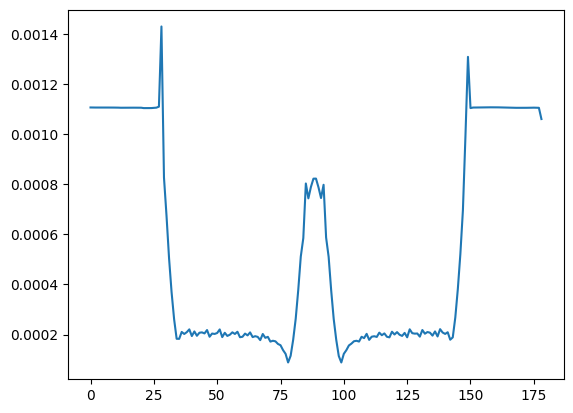

In [4]:
idt=[1]
for ii in idt:
    config_dict = {
        "sim_params": {
            "N": 2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-1e-7, 1e-7],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251225,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_1e-3_2e-7_001.npy",
                # "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_4merge_sample.npy",
                #80
                
                "materials":[['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8',1.06], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.472567], ['C8H8', 1.93762], ['C8H8', 2.402672], ['C8H8', 2.867725], ['C8H8', 3.332777], ['C8H8', 2.358152], ['C8H8', 2.79413], ['C8H8', 3.230108], ['C8H8', 3.666086], ['C8H8', 4.102064], ['C8H8', 4.181372], ['C8H8', 4.192097], ['C8H8', 4.168791], ['C8H8', 4.157365], ['C8H8', 4.145939], ['C8H8', 4.134514], ['C8H8', 4.119286], ['C8H8', 4.083412], ['C8H8', 4.065603], ['C8H8', 4.052678], ['C8H8', 4.034355], ['C8H8', 4.020007], ['C8H8', 3.967215], ['C8H8', 3.980062], ['C8H8', 3.992908], ['C8H8', 4.005254], ['C8H8', 3.940929], ['C8H8', 3.9231], ['C8H8', 3.905271], ['C8H8', 3.887442], ['C8H8', 3.864106], ['C8H8', 3.841035], ['C8H8', 3.817963], ['C8H8', 3.794891], ['C8H8', 3.775807], ['C8H8', 3.76336], ['C8H8', 3.851788], ['C8H8', 3.951348], ['C8H8', 3.726529], ['C8H8', 3.076403], ['C8H8', 2.505498], ['C8H8', 1.363687], ['C8H8', 0.792781], ['C8H8', 0.656895], ['C8H8', 0.594784], ['C8H8', 0.532673], ['C8H8', 0.470562], ['C8H8', 0.408451], ['C8H8', 0.369521], ['C8H8', 0.334443], ['C8H8', 0.299366], ['C8H8', 0.264288], ['C8H8', 0.229211], ['C8H8', 0.21643], ['C8H8', 0.198127], ['C8H8', 0.179825], ['C8H8', 0.161522], ['C8H8', 0.14322], ['C8H8', 0.124918], ['C8H8', 0.106615], ['C8H8', 0.088313], ['C8H8', 0.078172], ['C8H8', 0.067958], ['C8H8', 0.057744], ['C8H8', 0.047531], ['C8H8', 0.037287], ['C8H8', 0.027261], ['C8H8', 0.017236]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.660634], ['SiO2', 2.689968], ['SiO2', 2.719303], ['SiO2', 2.748638], ['SiO2', 2.777972], ['SiO2', 2.965927], ['SiO2', 3.83148], ['SiO2', 4.697032], ['SiO2', 5.562585], ['SiO2', 6.428138], ['SiO2', 7.014069], ['SiO2', 6.998661], ['SiO2', 6.983253], ['SiO2', 6.96666], ['SiO2', 6.955754], ['SiO2', 6.944849], ['SiO2', 6.933943], ['SiO2', 6.917133], ['SiO2', 6.899504], ['SiO2', 6.881876], ['SiO2', 6.864247], ['SiO2', 6.846618], ['SiO2', 6.834928], ['SiO2', 6.803993], ['SiO2', 6.773057], ['SiO2', 6.75056], ['SiO2', 6.73093], ['SiO2', 6.7113], ['SiO2', 6.69167], ['SiO2', 6.676234], ['SiO2', 6.658265], ['SiO2', 6.640296], ['SiO2', 6.582478], ['SiO2', 6.56511], ['SiO2', 6.547741], ['SiO2', 6.518184], ['SiO2', 6.497233], ['SiO2', 6.476283], ['SiO2', 6.455332], ['SiO2', 6.438912], ['SiO2', 6.405775], ['SiO2', 6.389207], ['SiO2', 6.371915], ['SiO2', 6.347083], ['SiO2', 6.322251], ['SiO2', 6.297418], ['SiO2', 6.272586], ['SiO2', 6.243858], ['SiO2', 6.231595], ['SiO2', 6.218689], ['SiO2', 6.205783], ['SiO2', 6.192876], ['SiO2', 6.11143], ['SiO2', 6.057242], ['SiO2', 6.046096], ['SiO2', 6.034951], ['SiO2', 6.023805], ['SiO2', 6.012659], ['SiO2', 5.973823], ['SiO2', 5.954253], ['SiO2', 5.934684], ['SiO2', 5.915114], ['SiO2', 5.895544], ['SiO2', 5.880792], ['SiO2', 5.859542], ['SiO2', 5.838291], ['SiO2', 5.789014], ['SiO2', 5.772886], ['SiO2', 5.756758], ['SiO2', 5.737114], ['SiO2', 5.710741], ['SiO2', 5.684367], ['SiO2', 5.657994], ['SiO2', 5.642045], ['SiO2', 5.583917], ['SiO2', 5.520054], ['SiO2', 5.507508], ['SiO2', 5.461704], ['SiO2', 5.444095], ['SiO2', 5.426487], ['SiO2', 5.408878], ['SiO2', 5.391269], ['C8H8', 5.154639], ['C8H8', 4.773428], ['C8H8', 4.392217], ['C8H8', 4.011007], ['C8H8', 3.629796], ['C8H8', 3.47748], ['C8H8', 3.496209], ['C8H8', 3.514939], ['C8H8', 3.46373], ['C8H8', 3.448743], ['C8H8', 3.427242], ['C8H8', 3.408452], ['C8H8', 3.389663], ['C8H8', 3.379072], ['C8H8', 3.363644], ['C8H8', 3.348217], ['C8H8', 3.327711], ['C8H8', 3.316265], ['C8H8', 3.304819], ['C8H8', 3.28322], ['C8H8', 3.265751], ['C8H8', 3.248282], ['C8H8', 3.227283], ['C8H8', 3.212976], ['C8H8', 3.201172], ['C8H8', 3.190107], ['C8H8', 3.179041], ['C8H8', 3.155514], ['C8H8', 3.140747], ['C8H8', 3.125979], ['C8H8', 3.089821], ['C8H8', 3.075614], ['C8H8', 3.061407], ['C8H8', 3.047574], ['C8H8', 3.036088], ['C8H8', 3.010959], ['C8H8', 2.995752], ['C8H8', 2.980544], ['C8H8', 2.969093], ['C8H8', 2.958848], ['C8H8', 2.948603], ['C8H8', 2.938358], ['C8H8', 2.911571], ['C8H8', 2.901546], ['C8H8', 2.881413], ['C8H8', 2.869107], ['C8H8', 2.850827], ['C8H8', 2.839221], ['C8H8', 2.827615], ['C8H8', 2.816009], ['C8H8', 2.793787], ['C8H8', 2.777819], ['C8H8', 2.761851], ['C8H8', 2.751419], ['C8H8', 2.737412], ['C8H8', 2.72198], ['C8H8', 2.707813], ['C8H8', 2.692889], ['C8H8', 2.678375], ['C8H8', 2.664088], ['C8H8', 2.648603], ['C8H8', 2.635476], ['C8H8', 2.619519], ['C8H8', 2.606793], ['C8H8', 2.589811], ['C8H8', 2.577329], ['C8H8', 2.565843], ['C8H8', 2.554109], ['C8H8', 2.528559], ['C8H8', 2.513611], ['C8H8', 2.498199], ['C8H8', 2.482391], ['C8H8', 2.468045], ['C8H8', 2.456346], ['C8H8', 2.446021], ['C8H8', 2.432778], ['C8H8', 2.419091], ['C8H8', 2.405405], ['C8H8', 2.393327], ['C8H8', 2.382034], ['C8H8', 2.368307], ['C8H8', 2.35458], ['C8H8', 2.341223], ['C8H8', 2.329632], ['C8H8', 2.317546], ['C8H8', 2.298229], ['C8H8', 2.287584], ['C8H8', 2.274456], ['C8H8', 2.259088], ['C8H8', 2.24329], ['C8H8', 2.21939], ['C8H8', 2.195638], ['C8H8', 2.171886], ['C8H8', 2.148134], ['C8H8', 2.124382], ['C8H8', 1.94572], ['C8H8', 1.88709], ['C8H8', 1.828461], ['C8H8', 1.769832], ['C8H8', 1.711202], ['C8H8', 1.542975], ['C8H8', 1.529608], ['C8H8', 1.516241], ['C8H8', 1.506145], ['C8H8', 1.488307], ['C8H8', 1.471533], ['C8H8', 1.455424], ['C8H8', 1.435671], ['C8H8', 1.418988], ['C8H8', 1.406517], ['C8H8', 1.394991], ['C8H8', 1.381576], ['C8H8', 1.366454], ['C8H8', 1.356429], ['C8H8', 1.345234], ['C8H8', 1.326831], ['C8H8', 1.314679], ['C8H8', 1.291232], ['C8H8', 1.279182], ['C8H8', 1.267335], ['C8H8', 1.25287], ['C8H8', 1.242184], ['C8H8', 1.229417], ['C8H8', 1.216007], ['C8H8', 1.20211], ['C8H8', 1.181088], ['C8H8', 1.165589], ['C8H8', 1.152142], ['C8H8', 1.136553], ['C8H8', 1.125228], ['C8H8', 1.11191], ['C8H8', 1.099998], ['C8H8', 1.087391], ['C8H8', 1.075244], ['C8H8', 1.057239], ['C8H8', 1.026002], ['C8H8', 1.015557], ['C8H8', 1.004741], ['C8H8', 0.992404], ['C8H8', 0.981071], ['C8H8', 0.968152], ['C8H8', 0.95594], ['C8H8', 0.94334], ['C8H8', 0.932484], ['C8H8', 0.921537], ['C8H8', 0.907734], ['C8H8', 0.894444], ['C8H8', 0.877199], ['C8H8', 0.866644], ['C8H8', 0.856321], ['C8H8', 0.842184], ['C8H8', 0.830571], ['C8H8', 0.820555], ['C8H8', 0.807186], ['C8H8', 0.796331], ['C8H8', 0.78252], ['C8H8', 0.768961], ['C8H8', 0.757252], ['C8H8', 0.746854], ['C8H8', 0.735762], ['C8H8', 0.725554], ['C8H8', 0.715493], ['C8H8', 0.704549], ['C8H8', 0.692516], ['C8H8', 0.681846], ['C8H8', 0.671272], ['C8H8', 0.658949], ['C8H8', 0.647926], ['C8H8', 0.63639], ['C8H8', 0.624077], ['C8H8', 0.612836], ['C8H8', 0.601977], ['C8H8', 0.591413], ['C8H8', 0.577759], ['C8H8', 0.567019], ['C8H8', 0.556665], ['C8H8', 0.545423], ['C8H8', 0.535338], ['C8H8', 0.524777], ['C8H8', 0.513655], ['C8H8', 0.50231], ['C8H8', 0.490834], ['C8H8', 0.477796], ['C8H8', 0.467591], ['C8H8', 0.452482], ['C8H8', 0.424323], ['C8H8', 0.397469], ['C8H8', 0.370616], ['C8H8', 0.343763], ['C8H8', 0.316909], ['C8H8', 0.290056], ['C8H8', 0.263202], ['C8H8', 0.236349], ['C8H8', 0.209495], ['C8H8', 0.182642], ['C8H8', 0.169441], ['C8H8', 0.15734], ['C8H8', 0.14524], ['C8H8', 0.13314], ['C8H8', 0.121039], ['C8H8', 0.108939], ['C8H8', 0.096839], ['C8H8', 0.084738], ['C8H8', 0.072638], ['C8H8', 0.060538], ['C8H8', 0.048437], ['C8H8', 0.036337], ['C8H8', 0.026323]]
    # if ii==1:
    #     config_dict["elements"][0]["materials"]=[['SiO2', 2.65],['SiO2', 2.65],['C8H8', 1.06],['C8H8', 1.06]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_time_sampleM_'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    # print(detector_x)

2025-12-26 00:05:37,119 INFO: Setting up simulation


dx:  8.294591680169107e-11
N:  268435456
Species:  4


2025-12-26 00:05:37,428 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_000537212243
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2025-12-26 00:05:37.704] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/12/20251226_000537212243/00000000
[2025-12-26 00:05:38.325] [info] Simulating optical element 1/1
[2025-12-26 00:05:38.335] [info] PreciseSample info:
[2025-12-26 00:05:38.335] [info]   z_len: 5000, x_len: 2000
[2025-12-26 00:05:38.335] [info]   material_deltabetas size: 5
[2025-12-26 00:05:38.335] [info]   Material 0: (0, 0)
[2025-12-26 00:05:38.335] [info]   Material 1: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:05:38.335] [info]   Material 2: (6.812085125940363e-06, 7.263280246911534e-08)
[2025-12-26 00:05:38.335] [info]   Material 3: (2.911163312614108e-06, 3.3128332796986215e-09)
[2025-12-26 00:05:38.335] [info]   Material 4: (2.911163312614108e-06, 3.3128332796986215e-09)
[2025-12-26 00:13:30.401] [info] Elapsed time for optical element: 472005.7 ms


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [07:53<00:00, 473.30s/it]

[2025-12-26 00:13:30.623] [info] Simulation finished in 501.216552417 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 179


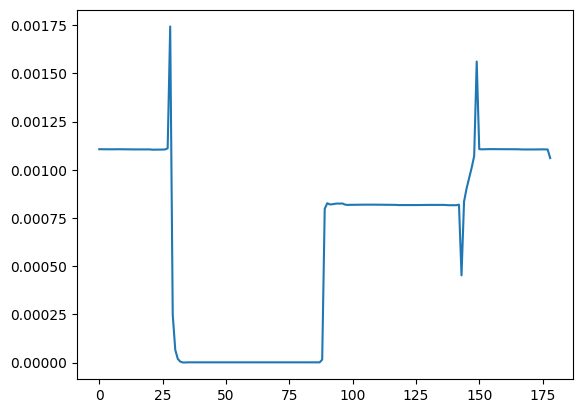

In [4]:
idt=[1]
for ii in idt:
    config_dict = {
        "sim_params": {
            "N": 2**28,
            "dx":propagation.max_dx(0.01, 2e-7, 2**28, propagation.convert_energy_wavelength(10000)),
            "z_detector":0.3,
            "detector_size": 18e-3,
            "detector_pixel_size_x": 1e-4,
            "detector_pixel_size_y": 1,
            "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9000-25, 9000+25],
            "x_range": [-1e-7, 1e-7],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 251225,
            #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 0.01,
                "pixel_size_x": 2 * 1e-7,
                "pixel_size_z": 2 * 1e-7,
                # "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_"+str(ii)+"_1e-3_2e-7_001.npy",
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/shockwave_4merge_sample.npy",
                #80
                
                "materials":[['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8',1.06], ['C8H8', 1.06], ['C8H8', 1.06], ['C8H8', 1.06]],
                "x_positions":[0*1e-4],
            },
        ],
    }
    if ii==80:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['C8H8', 1.06], ['C8H8', 1.472567], ['C8H8', 1.93762], ['C8H8', 2.402672], ['C8H8', 2.867725], ['C8H8', 3.332777], ['C8H8', 2.358152], ['C8H8', 2.79413], ['C8H8', 3.230108], ['C8H8', 3.666086], ['C8H8', 4.102064], ['C8H8', 4.181372], ['C8H8', 4.192097], ['C8H8', 4.168791], ['C8H8', 4.157365], ['C8H8', 4.145939], ['C8H8', 4.134514], ['C8H8', 4.119286], ['C8H8', 4.083412], ['C8H8', 4.065603], ['C8H8', 4.052678], ['C8H8', 4.034355], ['C8H8', 4.020007], ['C8H8', 3.967215], ['C8H8', 3.980062], ['C8H8', 3.992908], ['C8H8', 4.005254], ['C8H8', 3.940929], ['C8H8', 3.9231], ['C8H8', 3.905271], ['C8H8', 3.887442], ['C8H8', 3.864106], ['C8H8', 3.841035], ['C8H8', 3.817963], ['C8H8', 3.794891], ['C8H8', 3.775807], ['C8H8', 3.76336], ['C8H8', 3.851788], ['C8H8', 3.951348], ['C8H8', 3.726529], ['C8H8', 3.076403], ['C8H8', 2.505498], ['C8H8', 1.363687], ['C8H8', 0.792781], ['C8H8', 0.656895], ['C8H8', 0.594784], ['C8H8', 0.532673], ['C8H8', 0.470562], ['C8H8', 0.408451], ['C8H8', 0.369521], ['C8H8', 0.334443], ['C8H8', 0.299366], ['C8H8', 0.264288], ['C8H8', 0.229211], ['C8H8', 0.21643], ['C8H8', 0.198127], ['C8H8', 0.179825], ['C8H8', 0.161522], ['C8H8', 0.14322], ['C8H8', 0.124918], ['C8H8', 0.106615], ['C8H8', 0.088313], ['C8H8', 0.078172], ['C8H8', 0.067958], ['C8H8', 0.057744], ['C8H8', 0.047531], ['C8H8', 0.037287], ['C8H8', 0.027261], ['C8H8', 0.017236]]
    if ii==300:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65], ['SiO2', 2.660634], ['SiO2', 2.689968], ['SiO2', 2.719303], ['SiO2', 2.748638], ['SiO2', 2.777972], ['SiO2', 2.965927], ['SiO2', 3.83148], ['SiO2', 4.697032], ['SiO2', 5.562585], ['SiO2', 6.428138], ['SiO2', 7.014069], ['SiO2', 6.998661], ['SiO2', 6.983253], ['SiO2', 6.96666], ['SiO2', 6.955754], ['SiO2', 6.944849], ['SiO2', 6.933943], ['SiO2', 6.917133], ['SiO2', 6.899504], ['SiO2', 6.881876], ['SiO2', 6.864247], ['SiO2', 6.846618], ['SiO2', 6.834928], ['SiO2', 6.803993], ['SiO2', 6.773057], ['SiO2', 6.75056], ['SiO2', 6.73093], ['SiO2', 6.7113], ['SiO2', 6.69167], ['SiO2', 6.676234], ['SiO2', 6.658265], ['SiO2', 6.640296], ['SiO2', 6.582478], ['SiO2', 6.56511], ['SiO2', 6.547741], ['SiO2', 6.518184], ['SiO2', 6.497233], ['SiO2', 6.476283], ['SiO2', 6.455332], ['SiO2', 6.438912], ['SiO2', 6.405775], ['SiO2', 6.389207], ['SiO2', 6.371915], ['SiO2', 6.347083], ['SiO2', 6.322251], ['SiO2', 6.297418], ['SiO2', 6.272586], ['SiO2', 6.243858], ['SiO2', 6.231595], ['SiO2', 6.218689], ['SiO2', 6.205783], ['SiO2', 6.192876], ['SiO2', 6.11143], ['SiO2', 6.057242], ['SiO2', 6.046096], ['SiO2', 6.034951], ['SiO2', 6.023805], ['SiO2', 6.012659], ['SiO2', 5.973823], ['SiO2', 5.954253], ['SiO2', 5.934684], ['SiO2', 5.915114], ['SiO2', 5.895544], ['SiO2', 5.880792], ['SiO2', 5.859542], ['SiO2', 5.838291], ['SiO2', 5.789014], ['SiO2', 5.772886], ['SiO2', 5.756758], ['SiO2', 5.737114], ['SiO2', 5.710741], ['SiO2', 5.684367], ['SiO2', 5.657994], ['SiO2', 5.642045], ['SiO2', 5.583917], ['SiO2', 5.520054], ['SiO2', 5.507508], ['SiO2', 5.461704], ['SiO2', 5.444095], ['SiO2', 5.426487], ['SiO2', 5.408878], ['SiO2', 5.391269], ['C8H8', 5.154639], ['C8H8', 4.773428], ['C8H8', 4.392217], ['C8H8', 4.011007], ['C8H8', 3.629796], ['C8H8', 3.47748], ['C8H8', 3.496209], ['C8H8', 3.514939], ['C8H8', 3.46373], ['C8H8', 3.448743], ['C8H8', 3.427242], ['C8H8', 3.408452], ['C8H8', 3.389663], ['C8H8', 3.379072], ['C8H8', 3.363644], ['C8H8', 3.348217], ['C8H8', 3.327711], ['C8H8', 3.316265], ['C8H8', 3.304819], ['C8H8', 3.28322], ['C8H8', 3.265751], ['C8H8', 3.248282], ['C8H8', 3.227283], ['C8H8', 3.212976], ['C8H8', 3.201172], ['C8H8', 3.190107], ['C8H8', 3.179041], ['C8H8', 3.155514], ['C8H8', 3.140747], ['C8H8', 3.125979], ['C8H8', 3.089821], ['C8H8', 3.075614], ['C8H8', 3.061407], ['C8H8', 3.047574], ['C8H8', 3.036088], ['C8H8', 3.010959], ['C8H8', 2.995752], ['C8H8', 2.980544], ['C8H8', 2.969093], ['C8H8', 2.958848], ['C8H8', 2.948603], ['C8H8', 2.938358], ['C8H8', 2.911571], ['C8H8', 2.901546], ['C8H8', 2.881413], ['C8H8', 2.869107], ['C8H8', 2.850827], ['C8H8', 2.839221], ['C8H8', 2.827615], ['C8H8', 2.816009], ['C8H8', 2.793787], ['C8H8', 2.777819], ['C8H8', 2.761851], ['C8H8', 2.751419], ['C8H8', 2.737412], ['C8H8', 2.72198], ['C8H8', 2.707813], ['C8H8', 2.692889], ['C8H8', 2.678375], ['C8H8', 2.664088], ['C8H8', 2.648603], ['C8H8', 2.635476], ['C8H8', 2.619519], ['C8H8', 2.606793], ['C8H8', 2.589811], ['C8H8', 2.577329], ['C8H8', 2.565843], ['C8H8', 2.554109], ['C8H8', 2.528559], ['C8H8', 2.513611], ['C8H8', 2.498199], ['C8H8', 2.482391], ['C8H8', 2.468045], ['C8H8', 2.456346], ['C8H8', 2.446021], ['C8H8', 2.432778], ['C8H8', 2.419091], ['C8H8', 2.405405], ['C8H8', 2.393327], ['C8H8', 2.382034], ['C8H8', 2.368307], ['C8H8', 2.35458], ['C8H8', 2.341223], ['C8H8', 2.329632], ['C8H8', 2.317546], ['C8H8', 2.298229], ['C8H8', 2.287584], ['C8H8', 2.274456], ['C8H8', 2.259088], ['C8H8', 2.24329], ['C8H8', 2.21939], ['C8H8', 2.195638], ['C8H8', 2.171886], ['C8H8', 2.148134], ['C8H8', 2.124382], ['C8H8', 1.94572], ['C8H8', 1.88709], ['C8H8', 1.828461], ['C8H8', 1.769832], ['C8H8', 1.711202], ['C8H8', 1.542975], ['C8H8', 1.529608], ['C8H8', 1.516241], ['C8H8', 1.506145], ['C8H8', 1.488307], ['C8H8', 1.471533], ['C8H8', 1.455424], ['C8H8', 1.435671], ['C8H8', 1.418988], ['C8H8', 1.406517], ['C8H8', 1.394991], ['C8H8', 1.381576], ['C8H8', 1.366454], ['C8H8', 1.356429], ['C8H8', 1.345234], ['C8H8', 1.326831], ['C8H8', 1.314679], ['C8H8', 1.291232], ['C8H8', 1.279182], ['C8H8', 1.267335], ['C8H8', 1.25287], ['C8H8', 1.242184], ['C8H8', 1.229417], ['C8H8', 1.216007], ['C8H8', 1.20211], ['C8H8', 1.181088], ['C8H8', 1.165589], ['C8H8', 1.152142], ['C8H8', 1.136553], ['C8H8', 1.125228], ['C8H8', 1.11191], ['C8H8', 1.099998], ['C8H8', 1.087391], ['C8H8', 1.075244], ['C8H8', 1.057239], ['C8H8', 1.026002], ['C8H8', 1.015557], ['C8H8', 1.004741], ['C8H8', 0.992404], ['C8H8', 0.981071], ['C8H8', 0.968152], ['C8H8', 0.95594], ['C8H8', 0.94334], ['C8H8', 0.932484], ['C8H8', 0.921537], ['C8H8', 0.907734], ['C8H8', 0.894444], ['C8H8', 0.877199], ['C8H8', 0.866644], ['C8H8', 0.856321], ['C8H8', 0.842184], ['C8H8', 0.830571], ['C8H8', 0.820555], ['C8H8', 0.807186], ['C8H8', 0.796331], ['C8H8', 0.78252], ['C8H8', 0.768961], ['C8H8', 0.757252], ['C8H8', 0.746854], ['C8H8', 0.735762], ['C8H8', 0.725554], ['C8H8', 0.715493], ['C8H8', 0.704549], ['C8H8', 0.692516], ['C8H8', 0.681846], ['C8H8', 0.671272], ['C8H8', 0.658949], ['C8H8', 0.647926], ['C8H8', 0.63639], ['C8H8', 0.624077], ['C8H8', 0.612836], ['C8H8', 0.601977], ['C8H8', 0.591413], ['C8H8', 0.577759], ['C8H8', 0.567019], ['C8H8', 0.556665], ['C8H8', 0.545423], ['C8H8', 0.535338], ['C8H8', 0.524777], ['C8H8', 0.513655], ['C8H8', 0.50231], ['C8H8', 0.490834], ['C8H8', 0.477796], ['C8H8', 0.467591], ['C8H8', 0.452482], ['C8H8', 0.424323], ['C8H8', 0.397469], ['C8H8', 0.370616], ['C8H8', 0.343763], ['C8H8', 0.316909], ['C8H8', 0.290056], ['C8H8', 0.263202], ['C8H8', 0.236349], ['C8H8', 0.209495], ['C8H8', 0.182642], ['C8H8', 0.169441], ['C8H8', 0.15734], ['C8H8', 0.14524], ['C8H8', 0.13314], ['C8H8', 0.121039], ['C8H8', 0.108939], ['C8H8', 0.096839], ['C8H8', 0.084738], ['C8H8', 0.072638], ['C8H8', 0.060538], ['C8H8', 0.048437], ['C8H8', 0.036337], ['C8H8', 0.026323]]
    if ii==1:
        config_dict["elements"][0]["materials"]=[['SiO2', 2.65],['SiO2', 2.65],['C8H8', 1.06],['C8H8', 1.06]]
    print("dx: ", config_dict["sim_params"]["dx"])
    print("N: ", config_dict["sim_params"]["N"])
    print("Species: ",len(config_dict["elements"][0]["materials"]))
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    
    #print("cutoff angles:", computed['cutoff_angles'])
    #print("source points:", computed['source_points'])
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-5e-6, 5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_time_sampleM_'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    # print(detector_x)

In [ ]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)


In [ ]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-3e-6, 3e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1])

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_Alstair.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
#以下是历史仿真结果

In [ ]:
#double_ring_911_844_803_0d_1e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3dc_1e7.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
#double_ring_911_844_803_0d_1e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3dc_1e7.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
#double_ring_911_844_803_0d_3e-7.npy

sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_0d.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
#double_ring_911_844_803_3d_3e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3d.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
print(detector_x)

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
print(detector_x)

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")